# Prac 09

This notebook compares Poisson-equation solving with a custom Gauss-Seidel method and with SciPy sparse linear algebra.

In [1]:
from pathlib import Path
from time import perf_counter
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve

plt.rcParams['figure.figsize'] = [16, 10]
BASE = Path('..')
DATASETS = {'Dashcam lane': BASE / 'Prac_04' / 'data' / 'dashcam.jpg', 'Autobahn': BASE / 'Prac_04' / 'data' / 'autobahn.jpg', 'Sea': BASE / 'Prac_02' / 'data' / 'sea.jpg'}
DATASETS

{'Dashcam lane': WindowsPath('../Prac_04/data/dashcam.jpg'),
 'Autobahn': WindowsPath('../Prac_04/data/autobahn.jpg'),
 'Sea': WindowsPath('../Prac_02/data/sea.jpg')}

In [2]:
def build_mask(image):
    h, w = image.shape[:2]
    mask = np.zeros((h, w), dtype=bool)
    r0, r1 = int(0.25 * h), int(0.75 * h)
    c0, c1 = int(0.25 * w), int(0.75 * w)
    mask[r0:r1, c0:c1] = True
    return mask

def build_system(image, mask):
    image = image.astype(np.float64)
    h, w = image.shape
    indices = -np.ones((h, w), dtype=np.int32)
    coords = np.argwhere(mask)
    for idx, (r, c) in enumerate(coords):
        indices[r, c] = idx
    n = len(coords)
    A = sparse.lil_matrix((n, n), dtype=np.float64)
    b = np.zeros(n, dtype=np.float64)
    for idx, (r, c) in enumerate(coords):
        A[idx, idx] = 4.0
        b[idx] = 4 * image[r, c] - image[r - 1, c] - image[r + 1, c] - image[r, c - 1] - image[r, c + 1]
        for nr, nc in ((r - 1, c), (r + 1, c), (r, c - 1), (r, c + 1)):
            if mask[nr, nc]:
                A[idx, indices[nr, nc]] = -1.0
            else:
                b[idx] += image[nr, nc]
    return A.tocsr(), b, coords

def gauss_seidel(A, b, max_iter=400, tol=1e-5):
    x = np.zeros_like(b)
    diag = A.diagonal()
    residuals = []
    for _ in range(max_iter):
        for i in range(A.shape[0]):
            row_start = A.indptr[i]
            row_end = A.indptr[i + 1]
            cols = A.indices[row_start:row_end]
            vals = A.data[row_start:row_end]
            sigma = np.dot(vals, x[cols]) - diag[i] * x[i]
            x[i] = (b[i] - sigma) / diag[i]
        residual = np.linalg.norm(A @ x - b)
        residuals.append(residual)
        if residual < tol:
            break
    return x, residuals

def reconstruct(image, coords, values):
    result = image.copy().astype(np.float64)
    for idx, (r, c) in enumerate(coords):
        result[r, c] = values[idx]
    return np.clip(result, 0, 255).astype(np.uint8)

def solve_image(image_gray):
    mask = build_mask(image_gray)
    A, b, coords = build_system(image_gray, mask)
    start = perf_counter()
    gs_solution, gs_residuals = gauss_seidel(A, b)
    gs_time = perf_counter() - start
    start = perf_counter()
    sparse_solution = spsolve(A, b)
    sparse_time = perf_counter() - start
    return {'mask': mask, 'gs_img': reconstruct(image_gray, coords, gs_solution), 'sparse_img': reconstruct(image_gray, coords, sparse_solution), 'gs_time': gs_time, 'sparse_time': sparse_time, 'gs_residuals': gs_residuals, 'unknowns': len(coords)}

In [3]:
results = {}
for name, path in DATASETS.items():
    img_bgr = cv2.imread(str(path))
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, None, fx=0.35, fy=0.35)
    results[name] = {'original': img_gray, **solve_image(img_gray)}
[(name, res['unknowns'], res['gs_time'], res['sparse_time']) for name, res in results.items()]

[('Dashcam lane', 58800, 86.49889540002914, 0.41329119994770736),
 ('Autobahn', 10349, 13.786091200017836, 0.03301569999894127),
 ('Sea', 23232, 30.61593129998073, 0.16741080000065267)]

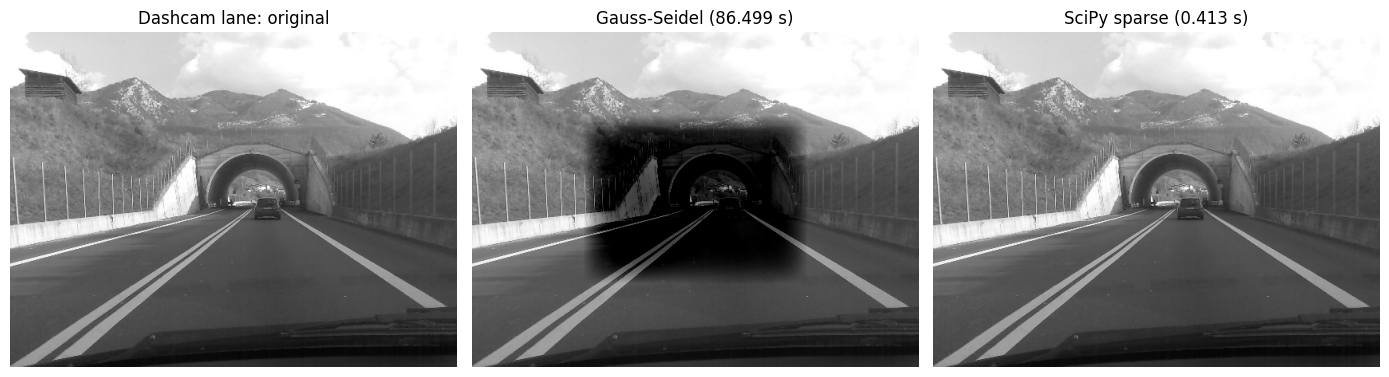

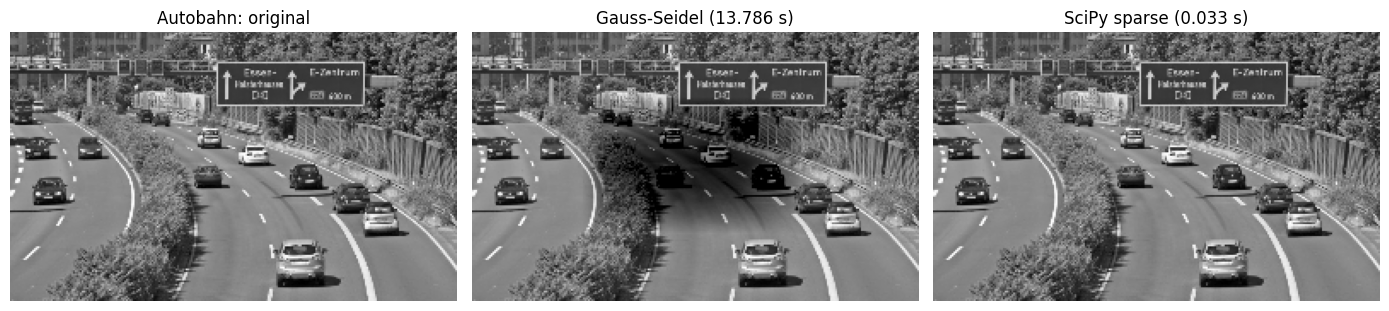

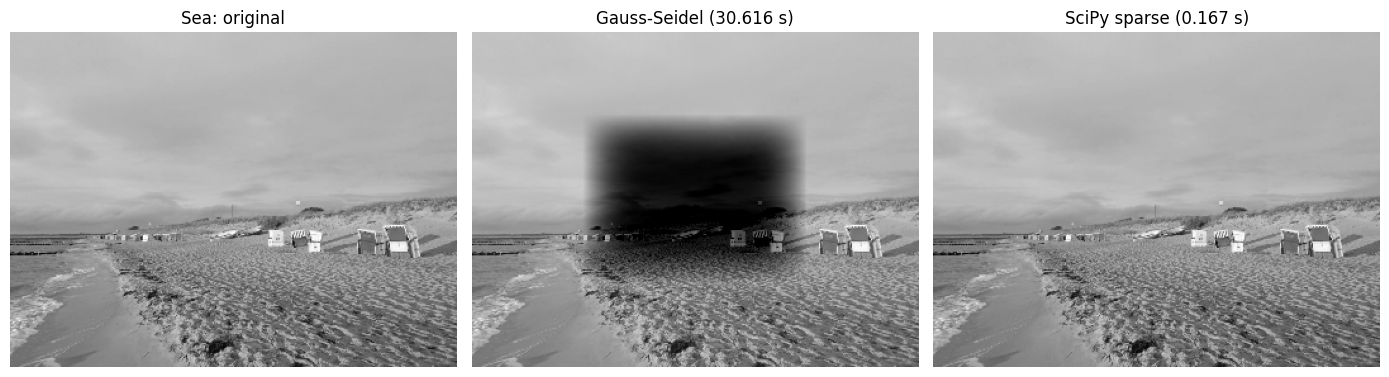

In [4]:
for name, res in results.items():
    plt.figure(figsize=(14, 4))
    plt.subplot(131)
    plt.imshow(res['original'], cmap='gray')
    plt.title(f'{name}: original')
    plt.axis('off')
    plt.subplot(132)
    plt.imshow(res['gs_img'], cmap='gray')
    plt.title(f'Gauss-Seidel ({res["gs_time"]:.3f} s)')
    plt.axis('off')
    plt.subplot(133)
    plt.imshow(res['sparse_img'], cmap='gray')
    plt.title(f'SciPy sparse ({res["sparse_time"]:.3f} s)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

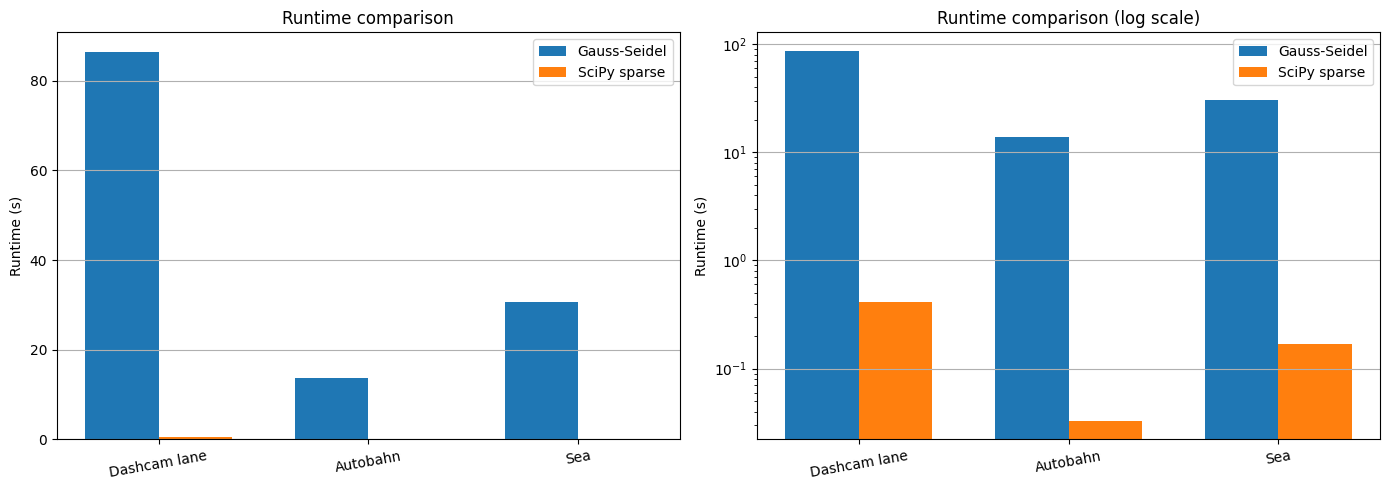

Dashcam lane: unknowns=58800, GS=86.4989s, sparse=0.4133s
Autobahn: unknowns=10349, GS=13.7861s, sparse=0.0330s
Sea: unknowns=23232, GS=30.6159s, sparse=0.1674s


In [5]:
names = list(results.keys())
gs_times = [results[name]['gs_time'] for name in names]
sparse_times = [results[name]['sparse_time'] for name in names]
x = np.arange(len(names))
width = 0.35
plt.figure(figsize=(14, 5))
plt.subplot(121)
plt.bar(x - width / 2, gs_times, width, label='Gauss-Seidel')
plt.bar(x + width / 2, sparse_times, width, label='SciPy sparse')
plt.xticks(x, names, rotation=10)
plt.ylabel('Runtime (s)')
plt.title('Runtime comparison')
plt.grid(True, axis='y')
plt.legend()
plt.subplot(122)
plt.bar(x - width / 2, gs_times, width, label='Gauss-Seidel')
plt.bar(x + width / 2, sparse_times, width, label='SciPy sparse')
plt.xticks(x, names, rotation=10)
plt.ylabel('Runtime (s)')
plt.yscale('log')
plt.title('Runtime comparison (log scale)')
plt.grid(True, axis='y')
plt.legend()
plt.tight_layout()
plt.show()
for name, res in results.items():
    print(f"{name}: unknowns={res['unknowns']}, GS={res['gs_time']:.4f}s, sparse={res['sparse_time']:.4f}s")

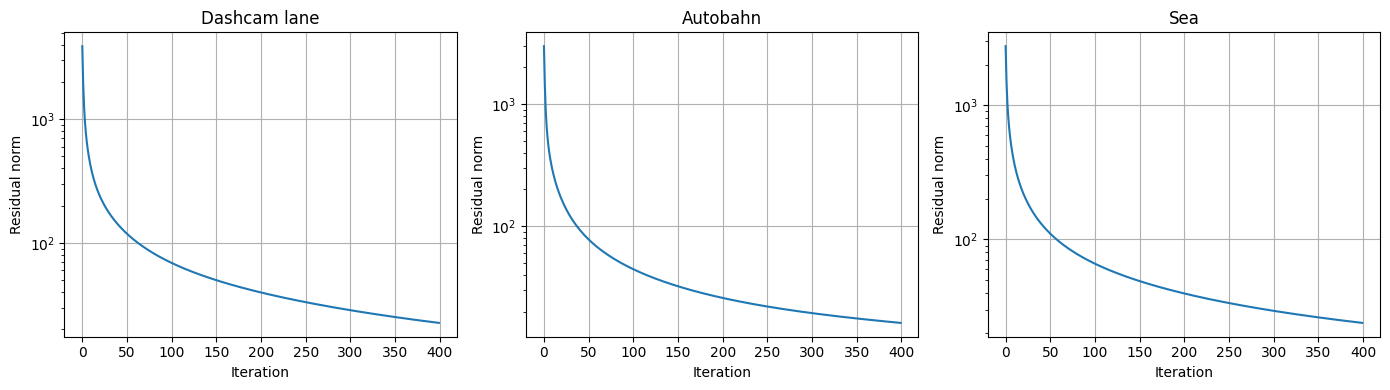

In [6]:
plt.figure(figsize=(14, 4))
for idx, (name, res) in enumerate(results.items(), start=1):
    plt.subplot(1, len(results), idx)
    plt.plot(res['gs_residuals'])
    plt.yscale('log')
    plt.grid(True)
    plt.title(name)
    plt.xlabel('Iteration')
    plt.ylabel('Residual norm')
plt.tight_layout()
plt.show()

### Conclusion

The sparse direct solver from SciPy is consistently much faster than the custom Gauss-Seidel implementation on all tested images. Gauss-Seidel is still useful for understanding iterative convergence, but sparse linear algebra is the practical choice for this task.